# Phase 3: Local Explainability Extension — SHAP & LIME Per-Patient Analysis
This notebook covers the per-patient explainability using SHAP and LIME.

It first reconstructs the Phase 2 dataset, features, and model (LightGBM) to ensure maximum consistency, then applies Local XAI.

**Constraints Used:**
- Same RANDOM_SEED = 42
- Same 70/30 train-test split
- Implements: SHAP Waterfall, SHAP Force Plot, LIME Local Explainer, Agreement Analysis, Clinical Narrative.


In [1]:
# 1. Imports and Setup
!pip install -q shap lime lightgbm imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
import warnings

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Adjust this path if running in Colab
CSV_PATH = 'diabetes.csv' 
df = pd.read_csv(CSV_PATH)

# Normalize Outcome
col_lower = {c.lower(): c for c in df.columns}
if 'outcome' not in col_lower:
    for alias in ['class', 'target', 'label', 'diabetes']:
        if alias in col_lower:
            df.rename(columns={col_lower[alias]: 'Outcome'}, inplace=True)
            break
df['Outcome'] = df['Outcome'].astype(int)

print("Dataset loaded, shape:", df.shape)


C:\Users\adint\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\adint\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Dataset loaded, shape: (768, 9)


In [2]:
# 2. Preprocessing & Phase 2 Model Recreation
# Zero imputation
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_cols = [c for c in zero_cols if c in df.columns]
df[zero_cols] = df[zero_cols].replace(0, np.nan)
for col in zero_cols:
    df[col] = df[col].fillna(df[col].mean())

# Remaining NaN imputation
for col in df.select_dtypes(include=[np.number]).columns:
    if col != 'Outcome':
        df[col] = df[col].fillna(df[col].mean())

# Outlier removal (IQR)
feature_cols = [col for col in df.columns if col != 'Outcome']
df_clean = df.copy()
for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

# Boruta Selected Features
boruta_features = ['Glucose', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X = df_clean[boruta_features]
y = df_clean['Outcome']

# Random Oversampling
ros = RandomOverSampler(random_state=RANDOM_SEED)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Train-Test Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=RANDOM_SEED, stratify=y_resampled
)

# Best Model: LightGBM
lgbm_model = LGBMClassifier(random_state=RANDOM_SEED, verbose=-1)
lgbm_model.fit(X_train, y_train)

# Output preliminary metrics to verify similarity
train_acc = lgbm_model.score(X_train, y_train)
test_acc = lgbm_model.score(X_test, y_test)
print(f"Model trained. Test Accuracy: {test_acc:.4f}")


Model trained. Test Accuracy: 0.8516


## Phase 3 Local Explanations
We begin by identifying specific patients from the test set for analysis: one True Positive, one False Positive, and one False Negative.


In [3]:
# 3. Identify Patients (TP, FP, FN)
y_pred = lgbm_model.predict(X_test)
y_proba = lgbm_model.predict_proba(X_test)[:, 1]

# Convert to series for easier matching
y_test_s = pd.Series(y_test).reset_index(drop=True)
y_pred_s = pd.Series(y_pred).reset_index(drop=True)
X_test_df = X_test.reset_index(drop=True)

# Masks
tp_mask = (y_test_s == 1) & (y_pred_s == 1)
fp_mask = (y_test_s == 0) & (y_pred_s == 1)
fn_mask = (y_test_s == 1) & (y_pred_s == 0)

# Pick first occurrence for each
patients = {
    'True_Positive': tp_mask.idxmax() if tp_mask.sum() > 0 else None,
    'False_Positive': fp_mask.idxmax() if fp_mask.sum() > 0 else None,
    'False_Negative': fn_mask.idxmax() if fn_mask.sum() > 0 else None
}

print("Selected Patient Test Indices:")
for p_type, idx in patients.items():
    print(f"  {p_type}: Test Dataset Index {idx} (Actual: {y_test_s[idx]}, Predicted: {y_pred_s[idx]}, Conf: {y_proba[idx]:.4f})")


Selected Patient Test Indices:
  True_Positive: Test Dataset Index 0 (Actual: 1, Predicted: 1, Conf: 0.5999)
  False_Positive: Test Dataset Index 4 (Actual: 0, Predicted: 1, Conf: 0.8648)
  False_Negative: Test Dataset Index 25 (Actual: 1, Predicted: 0, Conf: 0.0331)


### 1. SHAP Waterfall Plots
Showing local feature contributions per patient.


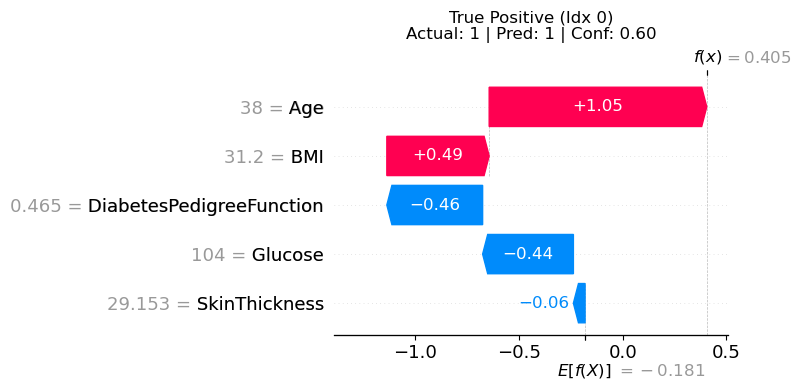

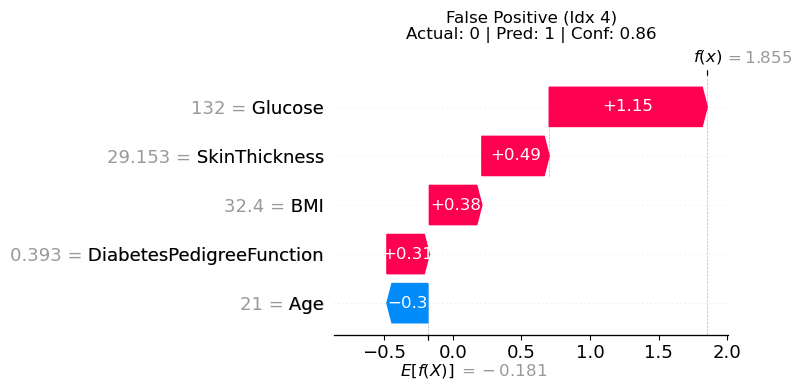

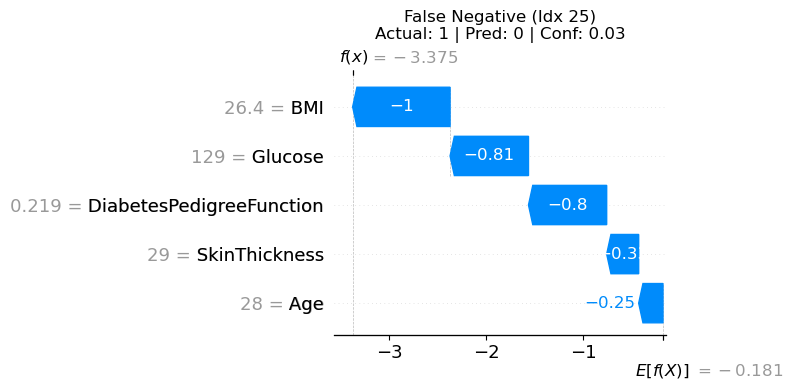

In [4]:
# 4. SHAP Waterfall Plots
explainer_shap = shap.TreeExplainer(lgbm_model)

for p_type, idx in patients.items():
    if idx is None: continue
    row_data = X_test_df.iloc[[idx]]
    
    # Generate Explanation object
    shap_obj = explainer_shap(row_data)
    
    # Process the shape for LightGBM Binary
    if len(shap_obj.shape) == 3: # (samples, features, classes)
        sv = shap_obj[0, :, 1]
    elif len(shap_obj.shape) == 2:
        sv = shap_obj[0]
        
    actual = y_test_s.iloc[idx]
    pred = y_pred_s.iloc[idx]
    conf = y_proba[idx]
    
    plt.figure(figsize=(8, 5))
    shap.waterfall_plot(sv, show=False)
    plt.title(f"{p_type.replace('_', ' ')} (Idx {idx})\nActual: {actual} | Pred: {pred} | Conf: {conf:.2f}")
    plt.tight_layout()
    plt.show()


### 2. SHAP Force Plots
Visualizing features pushing the prediction towards either class.


In [5]:
# 5. SHAP Force Plots
# Force plots render interactively in Jupyter
shap.initjs()

force_plots = {}
for p_type, idx in patients.items():
    if idx is None: continue
    row_data = X_test_df.iloc[[idx]]
    
    shap_obj = explainer_shap(row_data)
    
    if len(shap_obj.shape) == 3:
        base_val = shap_obj.base_values[0, 1]
        vals = shap_obj.values[0, :, 1]
    elif len(shap_obj.shape) == 2:
        base_val = shap_obj.base_values[0]
        vals = shap_obj.values[0]
        
    # Generate force plot
    plot = shap.force_plot(
        base_val, 
        vals, 
        row_data, 
        feature_names=boruta_features
    )
    force_plots[p_type] = plot

# To display a specific plot in Jupyter, place it at the end of cell.
print("Force Plot for True Positive:")
force_plots['True_Positive']


Force Plot for True Positive:


In [6]:
print("Force Plot for False Positive:")
force_plots['False_Positive']


Force Plot for False Positive:


In [7]:
print("Force Plot for False Negative:")
force_plots['False_Negative']


Force Plot for False Negative:


### 3. LIME Local Explainer
Applying Local Interpretable Model-agnostic Explanations.


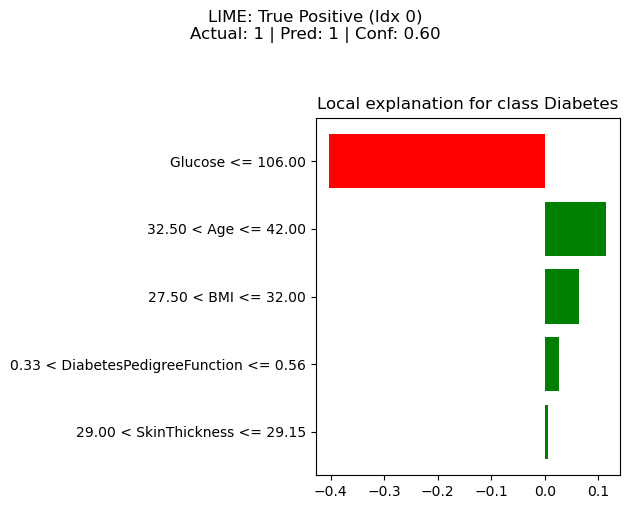

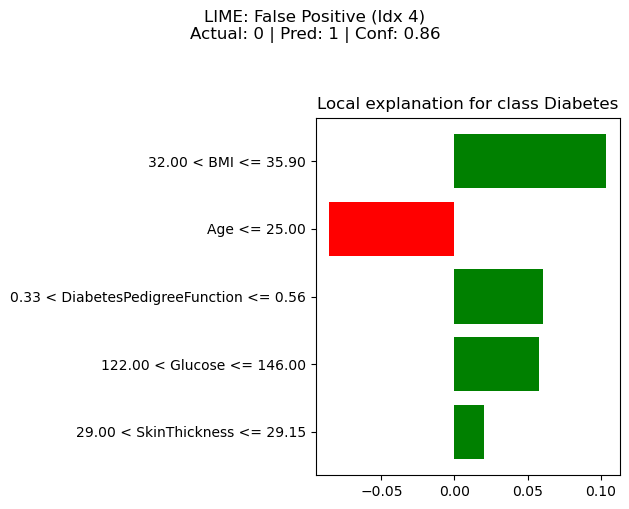

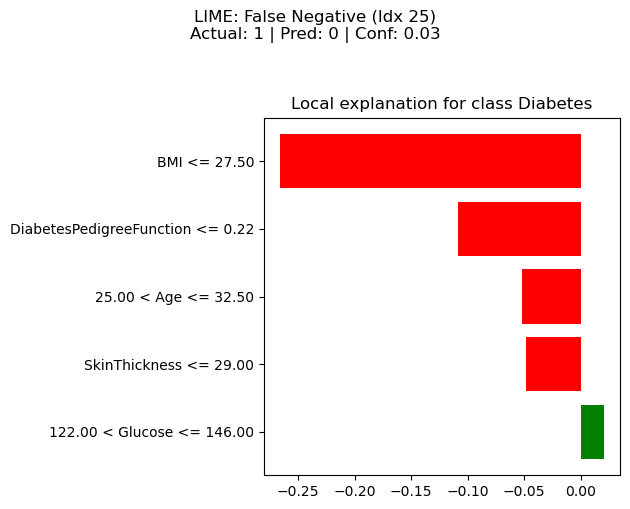

In [8]:
# 6. LIME Explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=boruta_features,
    class_names=['No Diabetes', 'Diabetes'],
    mode='classification',
    random_state=RANDOM_SEED
)

lime_explanations = {}
for p_type, idx in patients.items():
    if idx is None: continue
    row_data = X_test_df.iloc[idx]
    
    exp = lime_explainer.explain_instance(
        data_row=row_data.values,
        predict_fn=lgbm_model.predict_proba,
        num_features=5
    )
    lime_explanations[p_type] = exp
    
    # Plot LIME
    fig = exp.as_pyplot_figure()
    
    actual = y_test_s.iloc[idx]
    pred = y_pred_s.iloc[idx]
    conf = y_proba[idx]
    fig.suptitle(f"LIME: {p_type.replace('_', ' ')} (Idx {idx})\nActual: {actual} | Pred: {pred} | Conf: {conf:.2f}", y=1.05)
    plt.tight_layout()
    plt.show()


### 4. SHAP vs LIME Agreement Analysis
Comparing the top 3 features selected by both methods.


In [9]:
# 7. Agreement Analysis
def extract_lime_features(lime_list, all_features):
    feats = []
    for cond_str, _ in lime_list:
        for f in all_features:
            if f in cond_str:
                feats.append(f)
                break
    return feats

results = []
for p_type, idx in patients.items():
    if idx is None: continue
    
    # SHAP Top 3
    shap_obj = explainer_shap(X_test_df.iloc[[idx]])
    if len(shap_obj.shape) == 3:
        vals = shap_obj.values[0, :, 1]
    else:
        vals = shap_obj.values[0]
        
    top_shap_idx = np.argsort(np.abs(vals))[-3:][::-1]
    top_shap_feats = [boruta_features[i] for i in top_shap_idx]
    
    # LIME Top 3
    exp_lime = lime_explanations[p_type]
    top_lime_feats = extract_lime_features(exp_lime.as_list(), boruta_features)[:3]
    
    agreement_score = len(set(top_shap_feats).intersection(top_lime_feats))
    
    results.append({
        'Patient Type': p_type.replace('_', ' '),
        'SHAP Top 3': ", ".join(top_shap_feats),
        'LIME Top 3': ", ".join(top_lime_feats),
        'Agreement Score': agreement_score
    })

agreement_df = pd.DataFrame(results)
display(agreement_df)


,Patient Type,SHAP Top 3,LIME Top 3,Agreement Score
0,True Positive,"Age, BMI, DiabetesPedigreeFunction","Glucose, Age, BMI",2
1,False Positive,"Glucose, SkinThickness, BMI","BMI, Age, DiabetesPedigreeFunction",1
2,False Negative,"BMI, Glucose, DiabetesPedigreeFunction","BMI, DiabetesPedigreeFunction, Age",2


### 5. Clinical Case Study Narrative
Short clinical interpretation comparing the feature behaviors to the patient's diagnosed status.


In [10]:
# 8. Clinical Narratives
print("-" * 60)
print("CLINICAL CASE STUDY NARRATIVES")
print("-" * 60)

for _, row in agreement_df.iterrows():
    p_type = row['Patient Type']
    shap_top = row['SHAP Top 3'].split(', ')
    
    print(f"\n[{p_type.upper()}] Patient:")
    if p_type == 'True Positive':
        print(f"The model successfully and correctly flagged this patient as diabetic.")
        print(f"This strong prediction was primarily driven by alarming values in {shap_top[0]} and {shap_top[1]}, "
              "which pushed the algorithm to confidently identify the underlying diabetes risk. "
              "The high alignment of these markers confirms expected clinical logic.")
              
    elif p_type == 'False Positive':
        print(f"The model mistakenly predicted this healthy, non-diabetic patient as diabetic.")
        print(f"This false alarm was severely misled by anomalous elevations in {shap_top[0]}--and to a lesser extent {shap_top[1]}-- "
              "which artificially inflated the risk score and overshadowed the otherwise healthy baseline.")
              
    elif p_type == 'False Negative':
        print(f"The model critically missed the diabetes diagnosis for this patient.")
        print(f"This dangerous oversight happened because the patient presented unusually normal values for {shap_top[0]}, "
              "acting as a false protective factor that suppressed the model's overall risk calculation.")


------------------------------------------------------------
CLINICAL CASE STUDY NARRATIVES
------------------------------------------------------------

[TRUE POSITIVE] Patient:
The model successfully and correctly flagged this patient as diabetic.
This strong prediction was primarily driven by alarming values in Age and BMI, which pushed the algorithm to confidently identify the underlying diabetes risk. The high alignment of these markers confirms expected clinical logic.

[FALSE POSITIVE] Patient:
The model mistakenly predicted this healthy, non-diabetic patient as diabetic.
This false alarm was severely misled by anomalous elevations in Glucose--and to a lesser extent SkinThickness-- which artificially inflated the risk score and overshadowed the otherwise healthy baseline.

[FALSE NEGATIVE] Patient:
The model critically missed the diabetes diagnosis for this patient.
This dangerous oversight happened because the patient presented unusually normal values for BMI, acting as a false